In [87]:
import tensorflow as tf
import collections
import tensorflow_federated as tff

import src.config.constants_notebook as attack_consts

import numpy as np

In [88]:
import tensorflow.keras.backend as K
import gc

K.clear_session()  # Clear TF session to free GPU memory
gc.collect()

87055

In [89]:
print(tf.config.list_physical_devices('GPU'))
print(tf.__version__)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
2.14.1


In [90]:
import os

root = attack_consts.DATA_DIR
print("Exists:", os.path.exists(root))
print("Is dir:", os.path.isdir(root))

subs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
print("Subfolders (classes):", subs)
print("Num subfolders:", len(subs))

Exists: True
Is dir: True
Subfolders (classes): ['kidney_normal', 'kidney_tumor']
Num subfolders: 2


In [91]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
)

kidney_dataset = datagen.flow_from_directory(
    attack_consts.DATA_DIR,
    target_size=(224,224),
    class_mode='categorical',
    shuffle=True,
    seed=42,
    batch_size=32,
)

Found 10000 images belonging to 2 classes.


Batch shape: (32, 224, 224, 3)
Single image shape: (224, 224, 3)
Min pixel value: 0.0
Max pixel value: 1.0
Label [0. 1.]


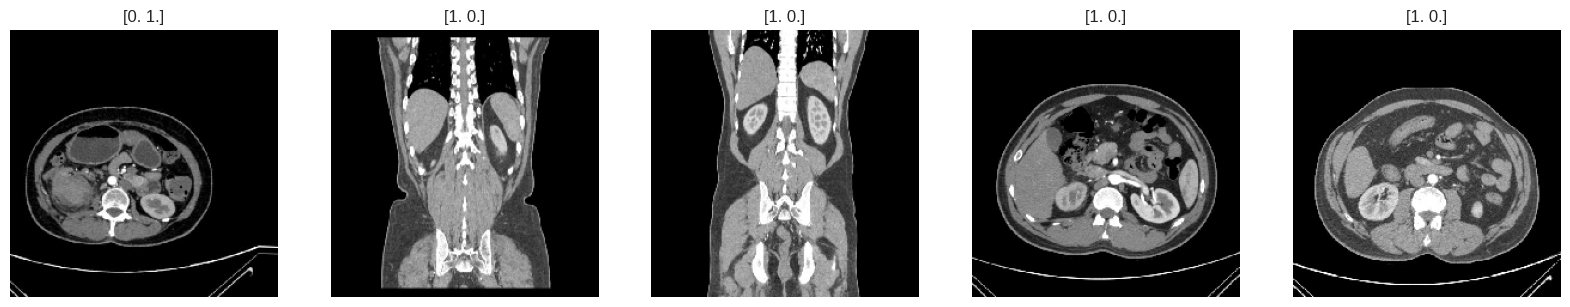

In [92]:
import matplotlib.pyplot as plt
images, labels = next(kidney_dataset)
for i in range(1):
    print("Batch shape:", images.shape)
    print("Single image shape:", images[0].shape)
    print("Min pixel value:", images.min())
    print("Max pixel value:", images.max())
    print("Label", labels[0])

fig, ax = plt.subplots(1, 5, figsize=(20,5))
for i in range(5):
    ax[i].imshow(images[i])
    ax[i].set_title(labels[i])
    ax[i].axis('off')

plt.show()


In [93]:
type(kidney_dataset)

keras.src.preprocessing.image.DirectoryIterator

In [94]:
import os

data_dir = attack_consts.DATA_DIR
class_names = os.listdir(data_dir)
class_labels = {name: idx for idx, name in enumerate(class_names)}

print(class_labels)

image_paths = []
labels = []
for class_name in class_names:
    path1 = os.path.join(data_dir, class_name)
    print(path1)
    paths = os.listdir(path1)
    for path in paths:
        image_paths.append(os.path.join(path1, path))
        labels.append(class_labels[class_name])

print(image_paths[1])

{'kidney_normal': 0, 'kidney_tumor': 1}
/home/mahesh/Desktop/Dissertation/tf_fd_cancer_fakeclients_detection/data/Kidney Cancer/kidney_normal
/home/mahesh/Desktop/Dissertation/tf_fd_cancer_fakeclients_detection/data/Kidney Cancer/kidney_tumor
/home/mahesh/Desktop/Dissertation/tf_fd_cancer_fakeclients_detection/data/Kidney Cancer/kidney_normal/kidney_normal_0403.jpg


In [95]:
### Helper function for loading the images
import os
import random

class_names = os.listdir(attack_consts.DATA_DIR)
class_labels = {name: idx for idx, name in enumerate(class_names)}

fake_clients = []

def load_image(path, img_size=(224, 224)):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = img / 255.0
    return img

## Attack Function

In [96]:
def label_flip_attack(labels, flip_prob, seed=42):
    labels = np.array(labels, dtype=np.int32).copy()
    rng = np.random.RandomState(seed)

    n = len(labels)
    num_classes = len(np.unique(labels))
    if n == 0 or num_classes < 2:
        return labels

    mask = rng.rand(n) < float(flip_prob)
    if mask.sum() > 0:
        rand_targets = rng.randint(0, num_classes, size=n)
        same = rand_targets == labels
        rand_targets[same] = (rand_targets[same] + 1) % num_classes
        labels[mask] = rand_targets[mask]

    return labels

In [97]:
def backdoor_attack(images, labels, target_label=0, poison_prob=0.4, trigger_value=1.0, seed=42):
    """
    Simple backdoor:
    - Poison a subset of samples
    - Add a small trigger patch at bottom-right
    - Force poisoned labels to target_label
    """
    labels = np.array(labels, dtype=np.int32).copy()
    rng = np.random.RandomState(seed)

    n = len(labels)
    if n == 0:
        return images, labels

    mask = rng.rand(n) < float(poison_prob)
    attacked_images = []

    for i, img in enumerate(images):
        if mask[i]:
            arr = img.numpy() if hasattr(img, "numpy") else np.array(img)
            h, w = arr.shape[:2]
            patch = max(2, min(h, w) // 12)
            arr[h - patch:h, w - patch:w, :] = trigger_value
            img = tf.convert_to_tensor(arr, dtype=tf.float32)
            labels[i] = int(target_label)
        attacked_images.append(img)

    return attacked_images, labels

In [98]:

def apply_attacks_for_client(images, labels, client_id, malicious_clients_attack_map, attack_params, seed=42):
    """
    malicious_clients_attack_map example:
    {
      "client_3": "label_flip",
      "client_7": "backdoor"
    }
    """
    attack_name = malicious_clients_attack_map.get(client_id)
    if not attack_name:
        return images, labels

    if attack_name == "label_flip":
        p = attack_params.get("label_flip", {})
        labels = label_flip_attack(
            labels=labels,
            flip_prob=p.get("flip_prob", 0.4),
            seed=p.get("seed", seed),
        )
        return images, labels

    if attack_name == "backdoor":
        p = attack_params.get("backdoor", {})
        return backdoor_attack(
            images=images,
            labels=labels,
            target_label=p.get("target_label", 0),
            poison_prob=p.get("poison_prob", 0.4),
            trigger_value=p.get("trigger_value", 1.0),
            seed=p.get("seed", seed),
        )

    return images, labels

In [99]:
def assign_fake_clients(
    num_client,
    num_malicious,
    attack_list,
    seed=42,
    exclude_head=True,
    additional_malicious_clients=None,
    max_fake_ratio=0.7,
    attack_distribution=None
):
    """
    - Excludes head client (client_0) if exclude_head=True
    - Can force-add specific malicious clients
    - attack_distribution lets you control attack percentages among malicious clients
    """
    rng = random.Random(seed)
    all_client_ids = [f"client_{i}" for i in range(num_client)]

    excluded = {"client_0"} if exclude_head else set()
    candidates = [cid for cid in all_client_ids if cid not in excluded]

    additional = set(additional_malicious_clients or [])
    additional = {cid for cid in additional if cid in candidates}

    max_allowed = int(num_client * max_fake_ratio)
    k_total = min(num_malicious, len(candidates), max_allowed)
    k_remaining = max(0, k_total - len(additional))

    remaining_pool = [cid for cid in candidates if cid not in additional]
    sampled = rng.sample(remaining_pool, k=min(k_remaining, len(remaining_pool)))

    malicious_clients = sorted(list(additional.union(sampled)))

    malicious_clients_attack_map = {}
    if not malicious_clients:
        return malicious_clients, malicious_clients_attack_map, all_client_ids

    if attack_distribution is None:
        for cid in malicious_clients:
            malicious_clients_attack_map[cid] = rng.choice(attack_list)
        return malicious_clients, malicious_clients_attack_map, all_client_ids

    # Keep only valid attacks with positive percentage/weight.
    filtered = {
        attack: float(weight)
        for attack, weight in attack_distribution.items()
        if attack in attack_list and float(weight) > 0.0
    }
    if not filtered:
        raise ValueError("attack_distribution must include at least one positive weight for an attack in attack_list")

    total_weight = sum(filtered.values())
    if total_weight <= 0:
        raise ValueError("Sum of attack_distribution weights must be > 0")

    k = len(malicious_clients)
    expected = {attack: (k * weight / total_weight) for attack, weight in filtered.items()}
    counts = {attack: int(np.floor(v)) for attack, v in expected.items()}
    remainder = k - sum(counts.values())

    # Assign leftover clients by largest fractional remainder.
    frac_order = sorted(
        expected.keys(),
        key=lambda a: (expected[a] - counts[a], expected[a]),
        reverse=True
    )
    for i in range(remainder):
        counts[frac_order[i % len(frac_order)]] += 1

    assigned_attacks = []
    for attack in attack_list:
        assigned_attacks.extend([attack] * counts.get(attack, 0))

    if len(assigned_attacks) != k:
        raise RuntimeError("Attack assignment count mismatch")

    rng.shuffle(assigned_attacks)
    for cid, attack in zip(malicious_clients, assigned_attacks):
        malicious_clients_attack_map[cid] = attack

    return malicious_clients, malicious_clients_attack_map, all_client_ids

In [100]:
def create_client_dataset(
    image_paths,
    label,
    client_id,
    malicious_clients_attack_map,
    attack_params,
    img_size=(224, 224),
    seed=42,
    batch_size=8,
    test_split=0.2
):
    images = []
    labels = []
    target_size = (64, 64)

    for i, path in enumerate(image_paths):
        img = load_image(path, img_size)
        img = tf.image.resize(img, target_size)
        images.append(img)
        labels.append(label[i])

    labels = np.array(labels, dtype=np.int32)

    n = len(images)
    if n == 0:
        empty_images = tf.zeros((0, target_size[0], target_size[1], 3), dtype=tf.float32)
        empty_labels = tf.zeros((0,), dtype=tf.int32)
        empty_ds = tf.data.Dataset.from_tensor_slices((empty_images, empty_labels)).batch(batch_size)
        return empty_ds, empty_ds

    indices = np.arange(n)
    split_rng = np.random.RandomState(seed)
    split_rng.shuffle(indices)

    raw_test_size = int(np.floor(n * float(test_split)))
    if n > 1 and test_split > 0:
        test_size = max(1, raw_test_size)
        test_size = min(test_size, n - 1)
    else:
        test_size = 0

    test_idx = indices[:test_size]
    train_idx = indices[test_size:]

    images_arr = np.stack([img.numpy() if tf.is_tensor(img) else img for img in images]).astype(np.float32)

    x_train = images_arr[train_idx]
    y_train = labels[train_idx]
    x_test = images_arr[test_idx]
    y_test = labels[test_idx]

    # Apply attacks only on train split; keep test split clean.
    train_images_list = [img for img in x_train]
    attacked_train_images, attacked_train_labels = apply_attacks_for_client(
        images=train_images_list,
        labels=np.array(y_train, dtype=np.int32),
        client_id=client_id,
        malicious_clients_attack_map=malicious_clients_attack_map,
        attack_params=attack_params,
        seed=seed
    )
    x_train = np.stack([img.numpy() if tf.is_tensor(img) else img for img in attacked_train_images]).astype(np.float32)
    y_train = np.array(attacked_train_labels, dtype=np.int32)

    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    if len(x_train) > 0:
        train_ds = train_ds.shuffle(buffer_size=len(x_train), seed=seed)
    train_ds = train_ds.batch(batch_size)

    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

    print(
        f"{client_id}: total={n}, train={len(x_train)}, test={len(x_test)}, "
        f"attack={malicious_clients_attack_map.get(client_id)}"
    )
    return train_ds, test_ds

In [101]:
def prepare_client_dataset(
    data_dir,
    num_client,
    num_malicious,
    attack_list,
    attack_params,
    seed=42,
    max_samples=10000,
    attack_distribution=None,
    test_split=0.2
):
    image_paths = []
    labels = []

    class_names = os.listdir(data_dir)
    class_labels = {name: idx for idx, name in enumerate(class_names)}
    print("class_labels:", class_labels)

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        for file_name in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, file_name))
            labels.append(class_labels[class_name])

    combined = list(zip(image_paths, labels))
    rng = random.Random(seed)
    rng.shuffle(combined)

    if max_samples is not None:
        combined = combined[:max_samples]

    image_paths, labels = zip(*combined)

    malicious_clients, malicious_clients_attack_map, all_client_ids = assign_fake_clients(
        num_client=num_client,
        num_malicious=num_malicious,
        attack_list=attack_list,
        seed=seed,
        exclude_head=True,
        additional_malicious_clients=[],   # put clients here if needed
        max_fake_ratio=0.7,
        attack_distribution=attack_distribution
    )

    print("malicious_clients:", malicious_clients)
    print("malicious_clients_attack_map:", malicious_clients_attack_map)

    clients_datasets = {}
    client_test_datasets = {}
    total_images = len(image_paths)

    for i, client_id in enumerate(all_client_ids):
        start = i * total_images // num_client
        end = ((i + 1) * total_images) // num_client

        train_ds, test_ds = create_client_dataset(
            image_paths=image_paths[start:end],
            label=labels[start:end],
            client_id=client_id,
            malicious_clients_attack_map=malicious_clients_attack_map,
            attack_params=attack_params,
            img_size=(224, 224),
            seed=seed + i,
            batch_size=8,
            test_split=test_split
        )
        clients_datasets[client_id] = train_ds
        client_test_datasets[client_id] = test_ds

    return clients_datasets, client_test_datasets, malicious_clients, malicious_clients_attack_map

In [102]:
attack_list = ["label_flip", "backdoor"]

attack_distribution = {
    "label_flip": 0.60,
    "backdoor": 0.40,
}

attack_params = {
    "label_flip": {"flip_prob": attack_consts.FLIP_PROB, "seed": attack_consts.SEED},
    "backdoor": {"target_label": 0, "poison_prob": 0.4, "trigger_value": 1.0, "seed": attack_consts.SEED},
}

client_datasets, client_test_datasets, fake_clients, fake_client_attack_map = prepare_client_dataset(
    data_dir=attack_consts.DATA_DIR,
    num_client=attack_consts.NUM_CLIENTS,
    num_malicious=attack_consts.NUM_MALICIOUS,
    attack_list=attack_list,
    attack_params=attack_params,
    seed=attack_consts.SEED,
    max_samples=10000,
    attack_distribution=attack_distribution,
    test_split=attack_consts.TEST_SPLIT
)

class_labels: {'kidney_normal': 0, 'kidney_tumor': 1}
malicious_clients: ['client_1', 'client_10', 'client_11', 'client_12', 'client_2', 'client_3', 'client_4', 'client_5', 'client_6']
malicious_clients_attack_map: {'client_1': 'backdoor', 'client_10': 'label_flip', 'client_11': 'backdoor', 'client_12': 'backdoor', 'client_2': 'label_flip', 'client_3': 'label_flip', 'client_4': 'label_flip', 'client_5': 'label_flip', 'client_6': 'backdoor'}
client_0: total=666, train=587, test=79, attack=None
client_1: total=667, train=587, test=80, attack=backdoor
client_2: total=667, train=587, test=80, attack=label_flip
client_3: total=666, train=587, test=79, attack=label_flip
client_4: total=667, train=587, test=80, attack=label_flip
client_5: total=667, train=587, test=80, attack=label_flip
client_6: total=666, train=587, test=79, attack=backdoor
client_7: total=667, train=587, test=80, attack=None
client_8: total=667, train=587, test=80, attack=None
client_9: total=666, train=587, test=79, attac

In [103]:
fake_clients

['client_1',
 'client_10',
 'client_11',
 'client_12',
 'client_2',
 'client_3',
 'client_4',
 'client_5',
 'client_6']

In [104]:
fake_client_attack_map

{'client_1': 'backdoor',
 'client_10': 'label_flip',
 'client_11': 'backdoor',
 'client_12': 'backdoor',
 'client_2': 'label_flip',
 'client_3': 'label_flip',
 'client_4': 'label_flip',
 'client_5': 'label_flip',
 'client_6': 'backdoor'}

In [105]:
client_datasets

{'client_0': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_1': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_2': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_3': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_4': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_5': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_6': <_B

In [106]:
client_test_datasets

{'client_0': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_1': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_2': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_3': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_4': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_5': <_BatchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
 'client_6': <_B

Client: client_0


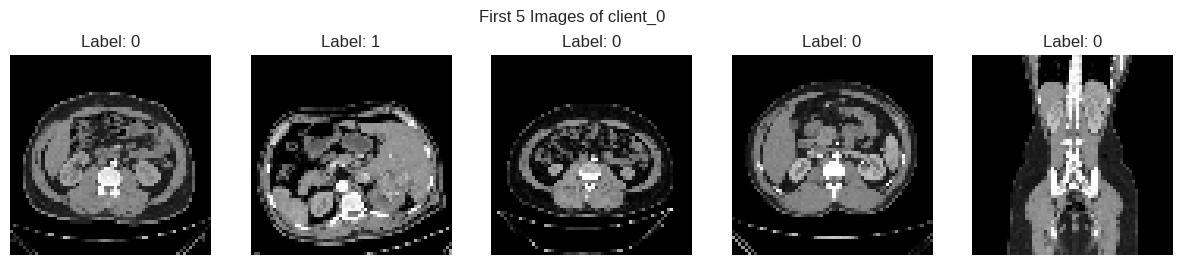

Client: client_1


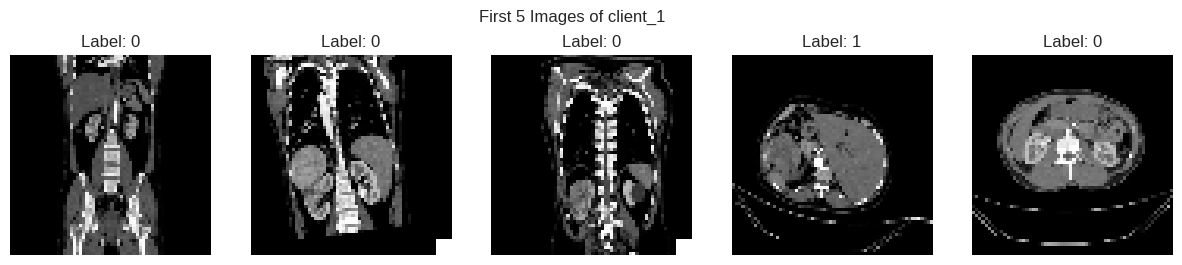

Client: client_2


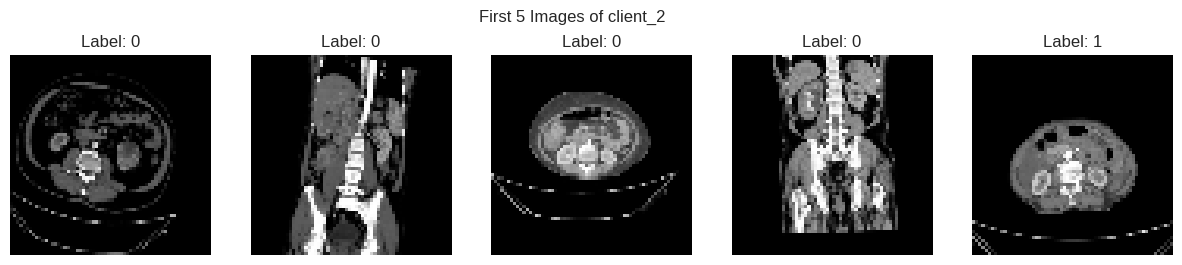

Client: client_3


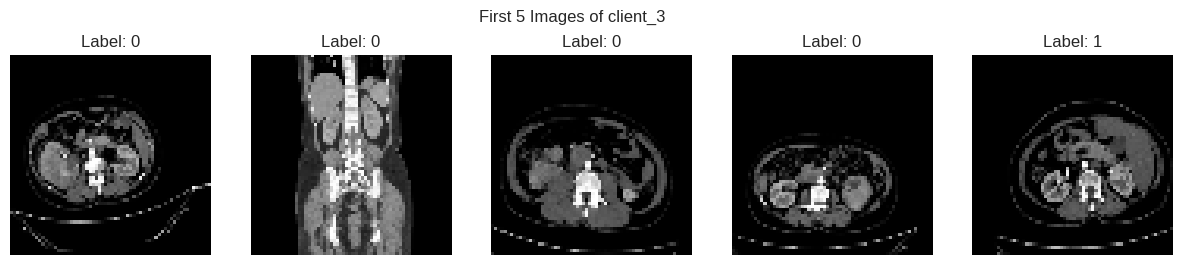

Client: client_4


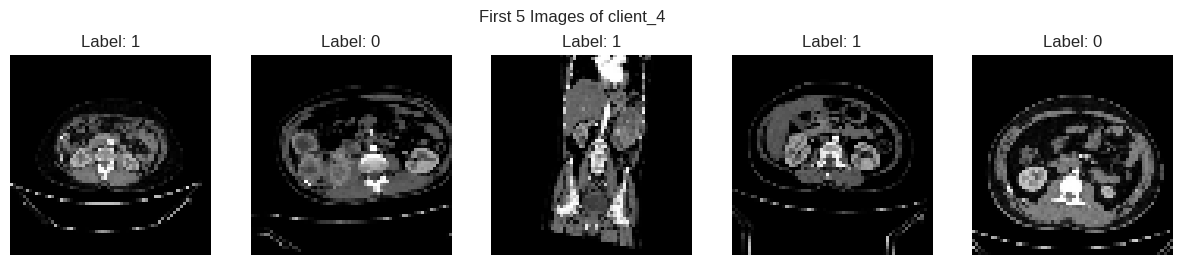

Client: client_5


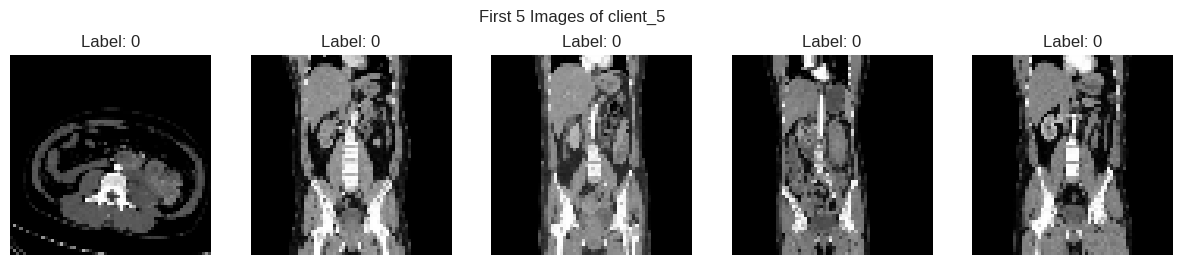

Client: client_6


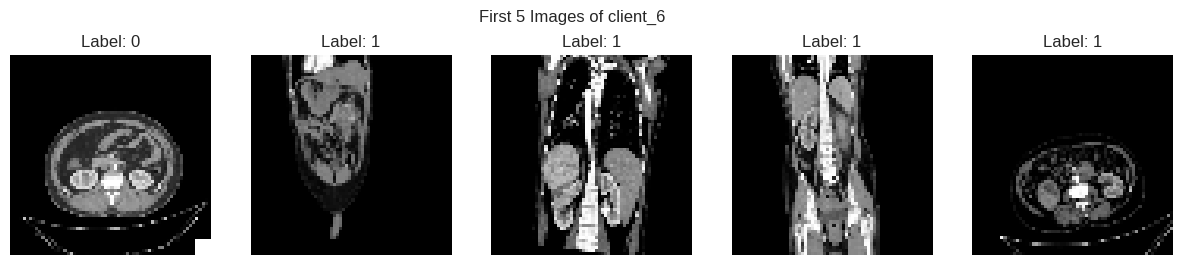

Client: client_7


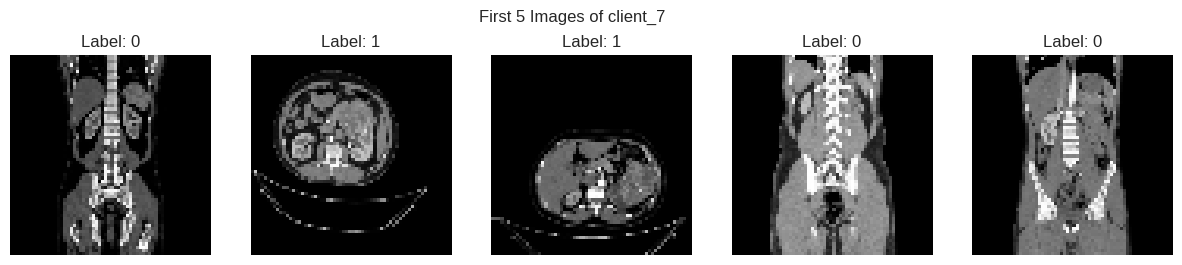

Client: client_8


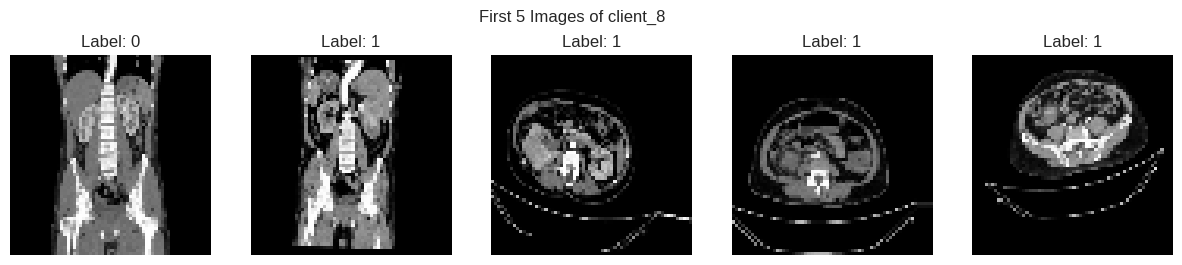

Client: client_9


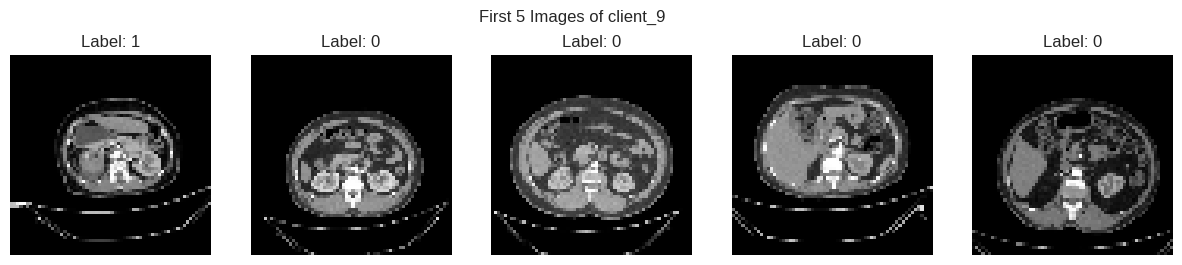

Client: client_10


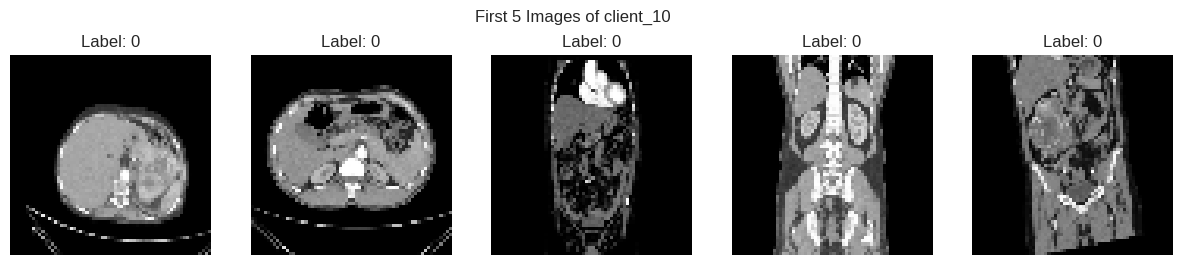

Client: client_11


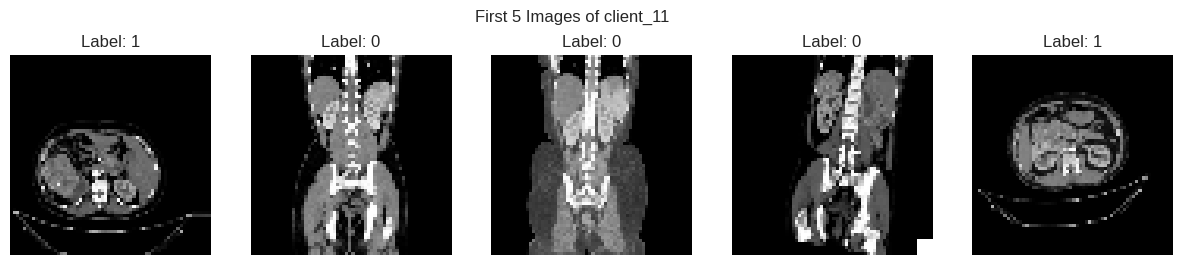

Client: client_12


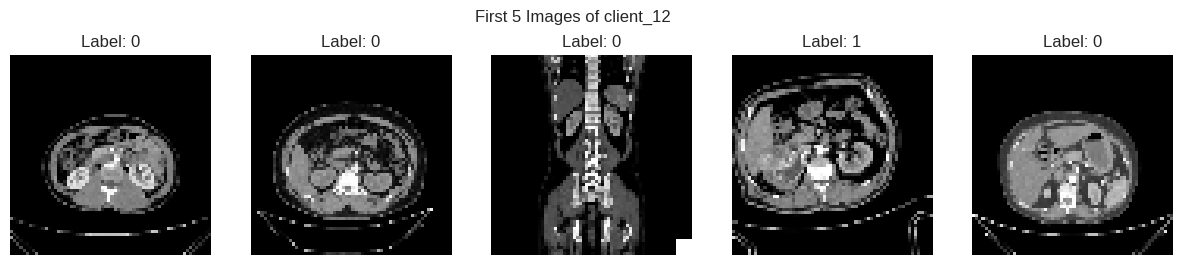

Client: client_13


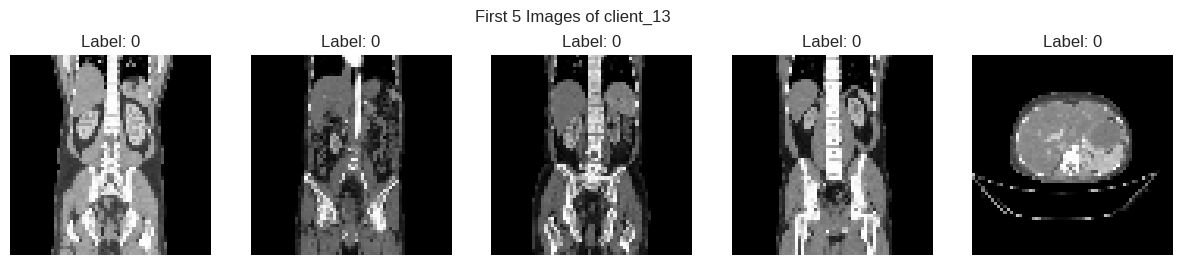

Client: client_14


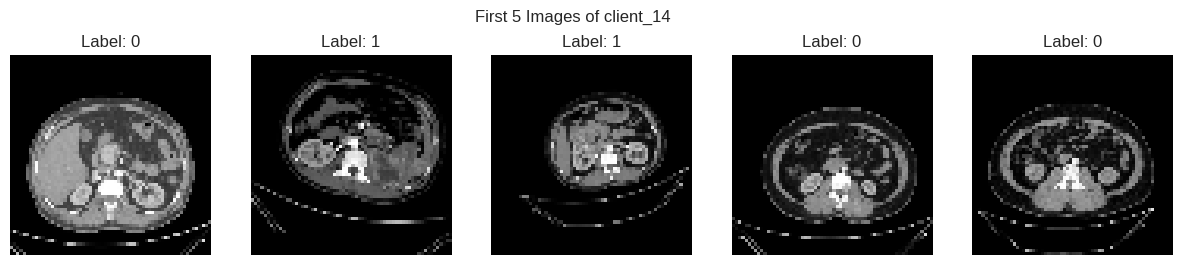

In [107]:
import matplotlib.pyplot as plt

def show_images_with_labels(images, labels, title=None):
    plt.figure(figsize=(15, 3))
    for i, (img, label) in enumerate(zip(images, labels)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis('off')
    if title:
        plt.suptitle(title)
    plt.show()

def print_first_5_images_with_labels(clients_datasets):
    for client_id, dataset in clients_datasets.items():
        print(f"Client: {client_id}")

        images_collected = []
        labels_collected = []
        for batch_images, batch_labels in dataset.take(1):
            images_slice = batch_images[:5]
            labels_slice = batch_labels[:5]
            batch_np_images = images_slice.numpy()
            batch_np_labels = labels_slice.numpy()
            for img, lbl in zip(batch_np_images, batch_np_labels):
                images_collected.append(img)
                labels_collected.append(lbl)

        show_images_with_labels(images_collected, labels_collected, title=f"First 5 Images of {client_id}")


print_first_5_images_with_labels(client_datasets)

In [108]:
for images, labels in client_datasets['client_0'].take(1):
    print(images.shape)
    print(labels.shape)
    print(labels)

(8, 64, 64, 3)
(8,)
tf.Tensor([1 0 1 0 0 0 0 1], shape=(8,), dtype=int32)


In [109]:
def create_keras_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(2, activation='softmax')  # For 2-class classification
    ])
    return model


In [110]:
def model_fn():
    keras_model = create_keras_model()
    return tff.learning.models.from_keras_model(
        keras_model,
        input_spec=client_datasets['client_0'].element_spec,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
    )

In [111]:
keras_model = create_keras_model()
tff_model = tff.learning.models.functional_model_from_keras(
        keras_model,
        input_spec=client_datasets['client_0'].element_spec,
        loss_fn =tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics_constructor = collections.OrderedDict(
            accuracy = tf.keras.metrics.SparseCategoricalAccuracy
        )
    )

2026-08-20 10:13:31.179018: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-20 10:13:31.179289: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-20 10:13:31.179418: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [112]:
sample_model = create_keras_model()

sample_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # for one-hot or multi-class
    metrics=['accuracy']
)

In [113]:
sample_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 31, 31, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 6, 6, 128)        

In [114]:
with tf.device('/GPU:0'):
    sample_model.fit(client_datasets['client_0'], epochs=5, verbose=2)

Epoch 1/5
74/74 - 1s - loss: 0.6809 - accuracy: 0.5741 - 869ms/epoch - 12ms/step
Epoch 2/5
74/74 - 0s - loss: 0.4261 - accuracy: 0.8024 - 206ms/epoch - 3ms/step
Epoch 3/5
74/74 - 0s - loss: 0.2603 - accuracy: 0.8893 - 209ms/epoch - 3ms/step
Epoch 4/5
74/74 - 0s - loss: 0.1729 - accuracy: 0.9455 - 234ms/epoch - 3ms/step
Epoch 5/5
74/74 - 0s - loss: 0.0675 - accuracy: 0.9847 - 102ms/epoch - 1ms/step


In [115]:
@tff.tensorflow.computation
def server_init():
    return tff.learning.models.ModelWeights(*tff_model.initial_weights)

In [116]:
@tff.federated_computation
def initialize_fn():
  return tff.federated_eval(server_init, tff.SERVER)

In [117]:
tf_dataset_type = tff.SequenceType(
    tff.types.tensorflow_to_type(tff_model.input_spec)
)

In [118]:
model_weights_type = server_init.type_signature.result

In [119]:
str(tf_dataset_type)

'<float32[?,64,64,3],int32[?]>*'

In [120]:
str(model_weights_type)

'<trainable=<float32[3,3,3,32],float32[32],float32[3,3,32,64],float32[64],float32[3,3,64,128],float32[128],float32[4608,128],float32[128],float32[128,2],float32[2]>,non_trainable=<>>'

In [121]:
@tf.function
def client_update(model, dataset, initial_weights, client_optimizer):
    """Performs client-side training and returns trainable weights + metrics."""
    client_weights = initial_weights.trainable

    optimizer_state = client_optimizer.initialize(
        tf.nest.map_structure(tf.TensorSpec.from_tensor, client_weights)
    )

    total_loss = tf.constant(0.0, dtype=tf.float32)
    total_correct = tf.constant(0.0, dtype=tf.float32)
    total_examples = tf.constant(0.0, dtype=tf.float32)

    for batch in dataset:
        x, y = batch

        with tf.GradientTape() as tape:
            tape.watch(client_weights)

            outputs = model.predict_on_batch(
                model_weights=(client_weights, ()),
                x=x,
                training=True
            )

            loss = model.loss(output=outputs, label=y)

        grads = tape.gradient(loss, client_weights)

        optimizer_state, client_weights = client_optimizer.next(
            optimizer_state,
            weights=client_weights,
            gradients=grads
        )

        batch_size = tf.cast(tf.shape(y)[0], tf.float32)
        preds = tf.argmax(outputs, axis=1, output_type=tf.int32)
        correct = tf.reduce_sum(tf.cast(tf.equal(preds, y), tf.float32))

        total_loss += loss * batch_size
        total_correct += correct
        total_examples += batch_size

    metrics = collections.OrderedDict(
        loss_sum=total_loss,
        correct_sum=total_correct,
        num_examples=total_examples
    )

    return client_weights, metrics

In [122]:
@tff.tensorflow.computation(tf_dataset_type, model_weights_type)
def client_update_fn(tf_dataset, server_weights):
  client_optimizer = tff.learning.optimizers.build_sgdm(learning_rate=0.01)
  return client_update(tff_model, tf_dataset, server_weights, client_optimizer)

In [123]:
@tff.tensorflow.computation(
    collections.OrderedDict(
        loss_sum=tf.float32,
        correct_sum=tf.float32,
        num_examples=tf.float32
    )
)
def finalize_round_metrics(metric_sums):
    return collections.OrderedDict(
        train_loss=metric_sums['loss_sum'] / metric_sums['num_examples'],
        train_accuracy=metric_sums['correct_sum'] / metric_sums['num_examples']
    )

In [124]:
@tf.function
def server_update(model, mean_client_weights):
  """Updates the server model weights as the average of the client model weights."""
  del model  # Unused, just take the mean_client_weights.
  return mean_client_weights

In [125]:
@tff.tensorflow.computation(model_weights_type)
def server_update_fn(mean_client_weights):
  return server_update(tff_model, mean_client_weights)

In [126]:
federated_server_type = tff.FederatedType(model_weights_type, tff.SERVER)
federated_dataset_type = tff.FederatedType(tf_dataset_type, tff.CLIENTS)

In [127]:
@tff.tensorflow.computation(model_weights_type.trainable)
def build_server_weights(trainable_weights):
    return tff.learning.models.ModelWeights(
        trainable=trainable_weights,
        non_trainable=()
    )

federated_server_type = tff.FederatedType(model_weights_type, tff.SERVER)
federated_dataset_type = tff.FederatedType(tf_dataset_type, tff.CLIENTS)

@tff.federated_computation(federated_server_type, federated_dataset_type)
def next_fn(server_weights, federated_dataset):

    server_weights_at_client = tff.federated_broadcast(server_weights)

    client_outputs = tff.federated_map(
        client_update_fn,
        (federated_dataset, server_weights_at_client)
    )

    client_trainable_weights = client_outputs[0]
    client_metrics = client_outputs[1]

    mean_trainable_weights = tff.federated_mean(client_trainable_weights)
    metric_sums = tff.federated_sum(client_metrics)

    new_server_weights = tff.federated_map(build_server_weights, mean_trainable_weights)
    round_metrics = tff.federated_map(finalize_round_metrics, metric_sums)

    return new_server_weights, client_trainable_weights, round_metrics

In [128]:
federated_algorithm = tff.templates.IterativeProcess(
    initialize_fn=initialize_fn,
    next_fn=next_fn
)

In [129]:
str(federated_algorithm.initialize.type_signature)

'( -> <trainable=<float32[3,3,3,32],float32[32],float32[3,3,32,64],float32[64],float32[3,3,64,128],float32[128],float32[4608,128],float32[128],float32[128,2],float32[2]>,non_trainable=<>>@SERVER)'

In [130]:
client_datasets_list = [client_datasets[key] for key in sorted(client_datasets.keys())]
client_datasets_list = list(client_datasets.values())

In [131]:
import os
import csv
from datetime import datetime

if attack_consts.STORE_RESULTS:
    results_dir = "federated_results"
    os.makedirs(results_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    metrics_file = os.path.join(
        results_dir,
        f"run_{timestamp}_fake_{attack_consts.NUM_MALICIOUS}.csv"
    )

    with open(metrics_file, "w", newline="") as f:
        f.write(f"# fake_clients: {attack_consts.NUM_MALICIOUS}\n")
        f.write(f"# total_rounds: {attack_consts.FEDERATED_ROUNDS}\n")
        writer = csv.writer(f)
        writer.writerow(["round", "loss", "accuracy"])


server_weights = server_init()
captured_client_weights = []
server_weights_track = []
server_weights_before_round = []

round_losses = []
round_accuracies = []

for r in range(attack_consts.FEDERATED_ROUNDS):

    server_weights_before_round.append(server_weights)
    server_weights, client_updates, round_metrics = next_fn(server_weights, client_datasets_list)

    captured_client_weights.append(client_updates)
    server_weights_track.append(server_weights)

    loss_value = float(round_metrics['train_loss'])
    acc_value = float(round_metrics['train_accuracy'])

    round_losses.append(loss_value)
    round_accuracies.append(acc_value)

    if attack_consts.STORE_RESULTS:
        with open(metrics_file, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([r+1, loss_value, acc_value])

    print(f"Finished Round {r+1}")
    print(f"Training Loss     : {loss_value:.4f}")
    print(f"Training Accuracy : {acc_value:.4f}")
    print("-" * 40)

2026-08-20 10:13:34.138323: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-20 10:13:34.138428: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-08-20 10:13:34.138486: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-08-20 10:13:34.138838: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-20 10:13:34.138931: I tensorflow/compiler/xla/stream_executor/

Finished Round 1
Training Loss     : 0.6700
Training Accuracy : 0.5717
----------------------------------------
Finished Round 2
Training Loss     : 0.6610
Training Accuracy : 0.5967
----------------------------------------
Finished Round 3
Training Loss     : 0.6527
Training Accuracy : 0.6159
----------------------------------------
Finished Round 4
Training Loss     : 0.6427
Training Accuracy : 0.6343
----------------------------------------
Finished Round 5
Training Loss     : 0.6313
Training Accuracy : 0.6462
----------------------------------------
Finished Round 6
Training Loss     : 0.6193
Training Accuracy : 0.6577
----------------------------------------
Finished Round 7
Training Loss     : 0.6070
Training Accuracy : 0.6673
----------------------------------------
Finished Round 8
Training Loss     : 0.5947
Training Accuracy : 0.6730
----------------------------------------
Finished Round 9
Training Loss     : 0.5821
Training Accuracy : 0.6844
---------------------------------


KeyboardInterrupt

I0000 00:00:1787238892.468635    6391 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(round_losses) + 1), round_losses, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Federated Round")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(round_accuracies) + 1), round_accuracies, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Federated Round")
plt.grid(True)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, len(round_losses) + 1), round_losses, marker='o')
ax[0].set_xlabel("Federated Round")
ax[0].set_ylabel("Training Loss")
ax[0].set_title("Training Loss vs Federated Round")
ax[0].grid(True)

ax[1].plot(range(1, len(round_accuracies) + 1), round_accuracies, marker='o')
ax[1].set_xlabel("Federated Round")
ax[1].set_ylabel("Training Accuracy")
ax[1].set_title("Training Accuracy vs Federated Round")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Final global model after federated training
final_server_weights = server_weights

# Build a fresh Keras model
final_model = create_keras_model()

# Load server weights into the Keras model
final_model.set_weights(list(final_server_weights.trainable))

# Compile before evaluation
final_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate on head client test dataset
head_test_ds = client_test_datasets['client_0']

test_loss, test_accuracy = final_model.evaluate(head_test_ds, verbose=1)

print("\nFinal Global Model Evaluation on Head Client (client_0) Test Set")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

In [ ]:
import math

# Build reverse label mapping
class_names = sorted(os.listdir(attack_consts.DATA_DIR))
idx_to_class = {idx: name for idx, name in enumerate(class_names)}

# Final trained global model
final_model = create_keras_model()
final_model.set_weights(list(server_weights.trainable))

final_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Take a few samples from head client test dataset
head_test_ds = client_test_datasets['client_0']

num_images = 8   # change as needed

sample_images = []
sample_true_labels = []

for batch_x, batch_y in head_test_ds:
    for i in range(len(batch_x)):
        sample_images.append(batch_x[i].numpy())
        sample_true_labels.append(int(batch_y[i].numpy()))
        if len(sample_images) >= num_images:
            break
    if len(sample_images) >= num_images:
        break

sample_images = np.array(sample_images)
sample_true_labels = np.array(sample_true_labels)

# Predict
pred_probs = final_model.predict(sample_images, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

# Plot
cols = 4
rows = math.ceil(num_images / cols)

plt.figure(figsize=(16, 4 * rows))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(sample_images[i])

    true_name = idx_to_class[sample_true_labels[i]]
    pred_name = idx_to_class[pred_labels[i]]

    plt.title(f"Original: {true_name}\nPredicted: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
len(captured_client_weights[0])

In [ ]:
len(captured_client_weights)

In [ ]:
captured_client_weights[0][1]

In [ ]:
client_weights = {}

for round_idx, round_client_weights in enumerate(captured_client_weights):
    round_key = f"round{round_idx}weights"
    client_weights[round_key] = {}

    for client_idx, weights_tuple in enumerate(round_client_weights):
        flat_vector = tf.concat(
            [tf.reshape(w, [-1]) for w in weights_tuple],
            axis=0
        )
        client_weights[round_key][f"client_{client_idx}"] = flat_vector

In [ ]:
client_weight_deltas = {}

for round_idx, round_client_weights in enumerate(captured_client_weights):
    round_key = f"round{round_idx}weights"
    client_weight_deltas[round_key] = {}

    # IMPORTANT: this must be the server weights BEFORE this round
    server_trainable = server_weights_track[round_idx].trainable

    for client_idx, client_trainable in enumerate(round_client_weights):

        # Layer-by-layer delta: client - server
        delta_tensors = [
            client_w - server_w
            for client_w, server_w in zip(
                client_trainable,
                server_trainable
            )
        ]

        # Flatten all layer deltas into one vector
        flat_delta = tf.concat(
            [tf.reshape(delta, [-1]) for delta in delta_tensors],
            axis=0
        )

        client_weight_deltas[round_key][f"client_{client_idx}"] = flat_delta

In [ ]:
client_weights = client_weight_deltas

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize

def cluster_one_round(client_weights_dict, n_clusters=2, pca_var=0.95):
    """
    client_weights_dict: {"client_0": tf.Tensor shape (D,), ..., "client_9": tf.Tensor shape (D,)}
    returns: labels (len=10), Z (10 x k), client_keys (ordered)
    """
    client_keys = sorted(client_weights_dict.keys(), key=lambda s: int(s.split("_")[1]))

    # Stack to (10, D)
    X = np.stack([client_weights_dict[k].numpy() for k in client_keys], axis=0).astype(np.float32)

    # Center/scale across clients (per-feature)
    X = X - X.mean(axis=0, keepdims=True)
    X_std = X.std(axis=0, keepdims=True)
    X_std[X_std == 0] = 1.0
    X_norm = X / X_std

    # PCA (works because n_samples=10, it will choose <=10 components)
    pca = PCA(n_components=pca_var, random_state=42)
    Z = pca.fit_transform(X_norm)

    # Normalize for cosine clustering (avoid zero-vector issues)
    Z_cos = normalize(Z, norm="l2")

    # Cluster
    clusterer = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric="cosine",
        linkage="average"
    )
    labels = clusterer.fit_predict(Z_cos)

    return labels, Z, client_keys


In [ ]:
round_cluster_results = {}

for r in range(4):
    round = f"round{r}weights"
    labels, Z, client_keys = cluster_one_round(client_weights[round], n_clusters=2, pca_var=0.95)

    round_cluster_results[round] = {
        "labels": labels,
        "client_keys": client_keys,
        "Z_shape": Z.shape
    }

    print(f"\n{round}  PCA shape={Z.shape}")
    for ck, lab in zip(client_keys, labels):
        print(f"  {ck} -> cluster {lab}")


In [ ]:
fake_client_attack_map

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage, dendrogram

def cluster_one_round_with_linkage(client_weights_dict, pca_var=0.95):
    client_keys = sorted(client_weights_dict.keys(), key=lambda s: int(s.split("_")[1]))

    # Stack to (n_clients, D)
    X = np.stack([client_weights_dict[k].numpy() for k in client_keys], axis=0).astype(np.float32)

    # Center + scale
    X = X - X.mean(axis=0, keepdims=True)
    X_std = X.std(axis=0, keepdims=True)
    X_std[X_std == 0] = 1.0
    X_norm = X / X_std

    # PCA
    pca = PCA(n_components=pca_var, random_state=42)
    Z = pca.fit_transform(X_norm)

    # Normalize for cosine distance
    Z_cos = normalize(Z, norm="l2")

    # --- Hierarchical linkage (THIS is the agglomerative tree) ---
    linkage_matrix = linkage(
        Z_cos,
        method="average",
        metric="cosine"
    )

    return linkage_matrix, Z, client_keys


In [ ]:
def plot_agglomerative_dendrogram(linkage_matrix, client_keys, round_name):
    plt.figure(figsize=(10, 5))
    dendrogram(
        linkage_matrix,
        labels=[ck.replace("client_", "C") for ck in client_keys],
        leaf_rotation=0,
        leaf_font_size=11,
        color_threshold=None
    )

    plt.title(
        f"{round_name}: Agglomerative Clustering Dendrogram\n"
        "(Average Linkage + Cosine Distance)",
        fontsize=14,
        weight="bold"
    )
    plt.xlabel("Clients")
    plt.ylabel("Cosine Distance")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
for r in range(4):
    rk = f"round{r}weights"
    linkage_matrix, Z, client_keys = cluster_one_round_with_linkage(
        client_weights[rk],
        pca_var=0.95
    )

    plot_agglomerative_dendrogram(linkage_matrix, client_keys, rk)


In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import hdbscan

def hdbscan_one_round(client_weights_dict, pca_var=0.95,
                      min_cluster_size=2, min_samples=1):
    client_keys = sorted(client_weights_dict.keys(), key=lambda s: int(s.split("_")[1]))

    # (n_clients, D)
    X = np.stack([client_weights_dict[k].numpy() for k in client_keys], axis=0).astype(np.float32)

    # Center/scale per-feature across clients
    X = X - X.mean(axis=0, keepdims=True)
    X_std = X.std(axis=0, keepdims=True)
    X_std[X_std == 0] = 1.0
    X_norm = X / X_std

    # PCA -> lower-dim features (stable for clustering + visualization)
    pca = PCA(n_components=pca_var, random_state=42)
    Z = pca.fit_transform(X_norm)

    # Normalize so cosine distance focuses on direction
    Z_cos = normalize(Z, norm="l2")

    # HDBSCAN: cosine metric + variable number of clusters + noise handling
    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_method="eom",   # typical default
    )
    labels = clusterer.fit_predict(Z_cos)          # -1 means noise/outlier
    probs  = clusterer.probabilities_              # confidence per point (0..1)

    return labels, probs, Z, client_keys, clusterer


In [ ]:
import os
import matplotlib.pyplot as plt

def plot_hdbscan_round(
    rk,
    labels,
    probs,
    Z,
    client_keys,
    save_dir=None,
    dpi=600,
    show=True
):
    """
    - Noise points (label=-1) are shown with red 'x' markers
    - Clustered points are color-coded and sized by membership confidence
    - Optional file export for paper-ready figures
    """
    if Z.shape[1] >= 2:
        x, y = Z[:, 0], Z[:, 1]
        xlab, ylab = "PCA-1", "PCA-2"
    else:
        x, y = Z[:, 0], np.zeros_like(Z[:, 0])
        xlab, ylab = "PCA-1", "0"

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#ffffff")

    unique_labels = sorted(set(labels))
    non_noise = [lab for lab in unique_labels if lab != -1]
    palette = plt.get_cmap("tab10", max(1, len(non_noise)))
    cluster_to_color = {lab: palette(i) for i, lab in enumerate(non_noise)}

    for lab in unique_labels:
        idx = labels == lab

        if lab == -1:
            ax.scatter(
                x[idx], y[idx],
                s=170,
                marker="x",
                linewidths=2.0,
                color="#d62728",
                alpha=0.95,
                label="Noise"
            )
        else:
            # Marker size encodes HDBSCAN confidence (0..1).
            sizes = 130 + 340 * probs[idx]
            ax.scatter(
                x[idx], y[idx],
                s=sizes,
                marker="o",
                color=cluster_to_color[lab],
                edgecolors="black",
                linewidths=0.9,
                alpha=0.88,
                label=f"Cluster {lab}"
            )

    for i, ck in enumerate(client_keys):
        ax.annotate(
            ck.replace("client_", "C"),
            (x[i], y[i]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color="#1f2937"
        )

    n_clusters = len(non_noise)
    n_noise = int((labels == -1).sum())
    ax.set_title(
        f"{rk}: HDBSCAN Clusters on PCA Features",
        fontsize=15,
        fontweight="bold",
        pad=12,
        color="#111827"
    )
    ax.set_xlabel(xlab, fontsize=12, fontweight="semibold", color="#111827")
    ax.set_ylabel(ylab, fontsize=12, fontweight="semibold", color="#111827")
    ax.tick_params(colors="#111827")
    for spine in ax.spines.values():
        spine.set_color("#9ca3af")

    subtitle = f"Clusters: {n_clusters} | Noise points: {n_noise}"
    ax.text(
        0.01, 0.99, subtitle,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", edgecolor="#9ca3af", boxstyle="round,pad=0.25")
    )

    ax.grid(True, which="major", alpha=0.28, linestyle="--", linewidth=0.8)
    legend = ax.legend(loc="best", frameon=True, fancybox=True, framealpha=0.95)
    legend.get_frame().set_edgecolor("#9ca3af")
    legend.get_frame().set_facecolor("white")
    for text in legend.get_texts():
        text.set_color("#111827")

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        out_png = os.path.join(save_dir, f"{rk}_hdbscan_publication.png")
        out_pdf = os.path.join(save_dir, f"{rk}_hdbscan_publication.pdf")
        fig.savefig(out_png, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")
        fig.savefig(out_pdf, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")
        print(f"Saved: {out_png}")
        print(f"Saved: {out_pdf}")

    if show:
        plt.show()
    else:
        plt.close(fig)

In [ ]:
round_hdbscan_results = {}
SAVE_DIR = "./figures/hdbscan"

for r in range(4):
    rk = f"round{r}weights"
    labels, probs, Z, client_keys, clusterer = hdbscan_one_round(
        client_weights[rk],
        pca_var=0.95,
        min_cluster_size=2,
        min_samples=1
    )

    round_hdbscan_results[rk] = {
        "labels": labels,
        "probs": probs,
        "client_keys": client_keys,
        "Z": Z
    }

    print(f"\n{rk}")
    for ck, lab, pr in zip(client_keys, labels, probs):
        print(f"  {ck} -> label {lab}   prob={pr:.3f}")

    plot_hdbscan_round(
        rk,
        labels,
        probs,
        Z,
        client_keys,
        save_dir=SAVE_DIR,
        dpi=600,
        show=True
    )

In [ ]:
def vector_magnitude(w):
    if isinstance(w, tf.Tensor):
        w = w.numpy()
    return np.linalg.norm(w, ord=2)

In [ ]:
def vector_direction(w, eps=1e-12):
    if isinstance(w, tf.Tensor):
        w = w.numpy()
    mag = np.linalg.norm(w)
    return w / (mag + eps)


In [ ]:
round_magnitudes = {}
round_directions = {}

for r in range(attack_consts.FEDERATED_ROUNDS):
    rk = f"round{r}weights"
    round_magnitudes[rk] = {}
    round_directions[rk] = {}

    for ck, w in client_weights[rk].items():
        mag = vector_magnitude(w)
        direction = vector_direction(w)

        round_magnitudes[rk][ck] = mag
        round_directions[rk][ck] = direction

        print(f"{rk} | {ck} | magnitude = {mag:.4f}")


In [ ]:
import os
from openpyxl import Workbook

def save_round_magnitudes_to_excel(round_magnitudes, total_clients, total_fake_clients, output_dir="federated_results"):
    os.makedirs(output_dir, exist_ok=True)

    file_name = f"magnitudes_totalClients_{total_clients}_fakeClients_{total_fake_clients}.xlsx"
    file_path = os.path.join(output_dir, file_name)

    wb = Workbook()

    # remove default sheet
    default_sheet = wb.active
    wb.remove(default_sheet)

    for round_name, client_data in round_magnitudes.items():
        ws = wb.create_sheet(title=round_name)

        # headers
        ws["A1"] = "Client ID"
        ws["B1"] = "Magnitude"

        # write client magnitudes
        for row_idx, (client_id, magnitude) in enumerate(client_data.items(), start=2):
            ws.cell(row=row_idx, column=1, value=client_id)
            ws.cell(row=row_idx, column=2, value=float(magnitude))

        # optional column widths
        ws.column_dimensions["A"].width = 20
        ws.column_dimensions["B"].width = 18

    wb.save(file_path)
    print(f"Saved Excel file: {file_path}")
    return file_path


# call the function
excel_file = save_round_magnitudes_to_excel(
    round_magnitudes=round_magnitudes,
    total_clients=attack_consts.NUM_CLIENTS,
    total_fake_clients=attack_consts.NUM_MALICIOUS
)

In [ ]:
import numpy as np
import tensorflow as tf

def angle_between_vectors(w1, w2, eps=1e-12):
    if isinstance(w1, tf.Tensor):
        w1 = w1.numpy()
    if isinstance(w2, tf.Tensor):
        w2 = w2.numpy()

    dot = np.dot(w1, w2)
    norm1 = np.linalg.norm(w1)
    norm2 = np.linalg.norm(w2)

    cos_sim = dot / (norm1 * norm2 + eps)
    cos_sim = np.clip(cos_sim, -1.0, 1.0)

    angle_rad = np.arccos(cos_sim)
    angle_deg = np.degrees(angle_rad)
    return angle_deg


In [ ]:
def print_all_client_angle_differences(client_weights_round):
    """
    client_weights_round:
      {"client_0": vector, "client_1": vector, ...}
    """
    client_keys = sorted(
        client_weights_round.keys(),
        key=lambda s: int(s.split("_")[1])
    )

    print("\nPairwise angle differences (degrees):")

    for i in range(len(client_keys)):
        for j in range(i + 1, len(client_keys)):
            c1 = client_keys[i]
            c2 = client_keys[j]

            angle = angle_between_vectors(
                client_weights_round[c1],
                client_weights_round[c2]
            )

            print(f"  {c1}   {c2} : {angle:.3f}")


In [ ]:
for r in range(attack_consts.FEDERATED_ROUNDS):
    rk = f"round{r}weights"
    print(f"\n================ {rk} ================")
    print_all_client_angle_differences(client_weights[rk])


In [ ]:
def save_angles_and_attack_map(
    client_weights,
    fake_client_attack_map,
    total_clients,
    total_fake_clients,
    output_dir="federated_results"
):

    os.makedirs(output_dir, exist_ok=True)

    file_name = f"client_angles_totalClients_{total_clients}_fakeClients_{total_fake_clients}.xlsx"
    file_path = os.path.join(output_dir, file_name)

    wb = Workbook()

    # remove default sheet
    default_sheet = wb.active
    wb.remove(default_sheet)

    for round_name, client_weights_round in client_weights.items():

        ws = wb.create_sheet(title=round_name)

        ws["A1"] = "Reference Client"
        ws["B1"] = "Other Client"
        ws["C1"] = "Angle Difference (Degrees)"

        client_keys = sorted(
            client_weights_round.keys(),
            key=lambda s: int(s.split("_")[1])
        )

        ref_client = "client_0"
        ref_vector = client_weights_round[ref_client]

        row = 2

        for client_id in client_keys:
            if client_id == ref_client:
                continue

            angle = angle_between_vectors(
                ref_vector,
                client_weights_round[client_id]
            )

            ws.cell(row=row, column=1, value=ref_client)
            ws.cell(row=row, column=2, value=client_id)
            ws.cell(row=row, column=3, value=angle)

            row += 1

    ws_map = wb.create_sheet(title="attack_mapping")

    ws_map["A1"] = "Client ID"
    ws_map["B1"] = "Attack Type"

    row = 2
    for client, attack in fake_client_attack_map.items():
        ws_map.cell(row=row, column=1, value=client)
        ws_map.cell(row=row, column=2, value=attack)
        row += 1

    wb.save(file_path)

    print("Saved:", file_path)
    return file_path


# Run it
save_angles_and_attack_map(
    client_weights=client_weights,
    fake_client_attack_map=fake_client_attack_map,
    total_clients=attack_consts.NUM_CLIENTS,
    total_fake_clients=attack_consts.NUM_MALICIOUS
)

In [ ]:
len(server_weights_track)

In [ ]:
server_weights_vector = {}

for i in range(len(server_weights_track)):
    model_weights = list(server_weights_track[i].trainable)
    model_to_flats = [tf.reshape(w, [-1]) for w in model_weights]
    flats_to_vector = tf.concat(model_to_flats, axis=0)
    server_weights_vector["round" + str(i)] = flats_to_vector

In [ ]:
len(server_weights_vector)

In [ ]:
server_client_angles = {}

num_rounds = len(server_weights_vector)

for r in range(num_rounds):
    rk_server = f"round{r}"
    rk_client = f"round{r}weights"

    s_vec = server_weights_vector[rk_server]

    # sort clients by index
    client_keys = sorted(client_weights[rk_client].keys(), key=lambda s: int(s.split("_")[1]))

    server_client_angles[rk_client] = {}

    print(f"\n=== {rk_client}: angle(client, server_round{r}) (degrees) ===")

    for ck in client_keys:
        c_vec = client_weights[rk_client][ck]

        # sanity check (dimensions must match)
        if int(c_vec.shape[0]) != int(s_vec.shape[0]):
            raise ValueError(
                f"Vector length mismatch in {rk_client} {ck}: "
                f"client={int(c_vec.shape[0])}, server={int(s_vec.shape[0])}. "
                f"Make sure you flattened the same weight set/order."
            )

        deg = angle_between_vectors(c_vec, s_vec)
        server_client_angles[rk_client][ck] = deg

        print(f"  {ck} -> {deg:.3f}")


In [ ]:
import matplotlib.pyplot as plt

for r in range(num_rounds):
    rk_client = f"round{r}weights"
    client_keys = sorted(server_client_angles[rk_client].keys(), key=lambda s: int(s.split("_")[1]))
    angles = [server_client_angles[rk_client][ck] for ck in client_keys]
    x = list(range(len(client_keys)))

    plt.figure(figsize=(9, 4))
    plt.plot(x, angles, marker="o")
    plt.xticks(x, [ck.replace("client_", "C") for ck in client_keys])
    plt.title(f"{rk_client}: Angle difference vs Server (degrees)")
    plt.xlabel("Client")
    plt.ylabel("Angle (degrees)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
